<a href="https://colab.research.google.com/github/Phil1263/Group-4-CNN-Image-Classification/blob/main/Final_Model(90_%2CGradio).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.



In [ ]:
from keras.backend import clear_session
clear_session()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
#
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


# Transfer learning

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Resize and convert to numpy float32
x_train_resized = tf.image.resize(x_train, (96, 96)).numpy().astype("float32")
x_test_resized = tf.image.resize(x_test, (96, 96)).numpy().astype("float32")

# Apply MobileNetV2 preprocessing
x_train_preprocessed = preprocess_input(x_train_resized)
x_test_preprocessed = preprocess_input(x_test_resized)

print(x_train_preprocessed.shape, x_train_preprocessed.dtype)
print(x_test_preprocessed.shape, x_test_preprocessed.dtype)

(50000, 96, 96, 3) float32
(10000, 96, 96, 3) float32


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2


base_model_mobilenet = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)

base_model_mobilenet.trainable = True
# keeps most of MobileNet frozen and only lets the last ~30 layers adapt.
for layer in base_model_mobilenet.layers[:-40]:
    layer.trainable = False
# check what is trainable
for i, layer in enumerate(base_model_mobilenet.layers[-40:]):
    print(i + len(base_model_mobilenet.layers) - 40, layer.name, layer.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
114 block_12_project_BN True
115 block_12_add True
116 block_13_expand True
117 block_13_expand_BN True
118 block_13_expand_relu True
119 block_13_pad True
120 block_13_depthwise True
121 block_13_depthwise_BN True
122 block_13_depthwise_relu True
123 block_13_project True
124 block_13_project_BN True
125 block_14_expand True
126 block_14_expand_BN True
127 block_14_expand_relu True
128 block_14_depthwise True
129 block_14_depthwise_BN True
130 block_14_depthwise_relu True
131 block_14_project True
132 block_14_project_BN True
133 block_14_add True
134 block_15_expand True
135 block_15_expand_BN True
136 block_15_expand_relu True
137 block_15_depthwise True
138 block_15_depthwise_BN True
139 block_15_depthwise_relu True
140 block_15_project True
141 block_15_project_BN True
142 block_15_add True
143 block_16_expand True
144 block_16_expand_BN True
145 block_16_expand_relu True
146 block_16_depthwise True
147 block_16_depthwise_BN True
14

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model_mobilenet4 = models.Sequential([
    layers.Input(shape=(96, 96, 3)),
    base_model_mobilenet,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [ ]:
# Compile
model_mobilenet4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_mobilenet4 = model_mobilenet4.fit(
    x_train_preprocessed,
    y_train,
    epochs=10,
    batch_size=16,
    validation_split=0.2
)



Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 63s 13ms/step - accuracy: 0.5262 - loss: 1.5212 - val_accuracy: 0.8264 - val_loss: 0.5233
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.7411 - loss: 0.8277 - val_accuracy: 0.8623 - val_loss: 0.4223
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.7854 - loss: 0.6799 - val_accuracy: 0.8788 - val_loss: 0.3739
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.8092 - loss: 0.6051 - val_accuracy: 0.8866 - val_loss: 0.3486
Epoch 5/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.8252 - loss: 0.5458 - val_accuracy: 0.8922 - val_loss: 0.3306
Epoch 6/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.8432 - loss: 0.4882 - val_accuracy: 0.8966 - val_loss: 0.3193
Epoch 7/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.8543 - loss: 0.4484 - val_accuracy: 0.8976 - val_loss: 0.3096
Epoch 8/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - accuracy: 0.8663 -

In [ ]:
model_mobilenet4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,127,072 (23.37 MB)

 Trainable params: 1,849,354 (7.05 MB)

 Non-trainable params: 579,008 (2.21 MB)

 Optimizer params: 3,698,710 (14.11 MB)

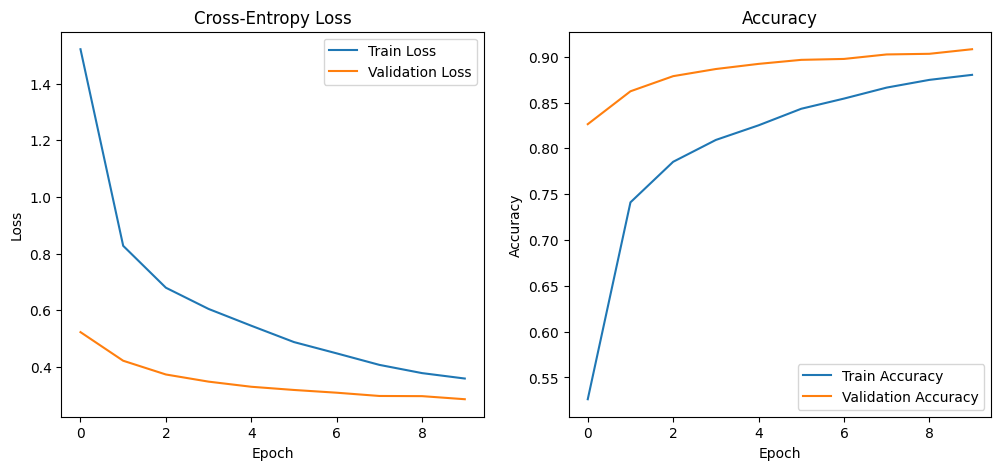

In [ ]:
plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(history_mobilenet4.history['loss'], label='Train Loss')
plt.plot(history_mobilenet4.history['val_loss'], label='Validation Loss')
plt.title('Cross-Entropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history_mobilenet4.history['accuracy'], label='Train Accuracy')
plt.plot(history_mobilenet4.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
test_loss, test_accuracy = model_mobilenet4.evaluate(x_test_preprocessed, y_test, verbose=1)
print("Test Accuracy for MobileNet4:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9028 - loss: 0.3056
Test Accuracy for MobileNet4: 0.9028000235557556


313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step


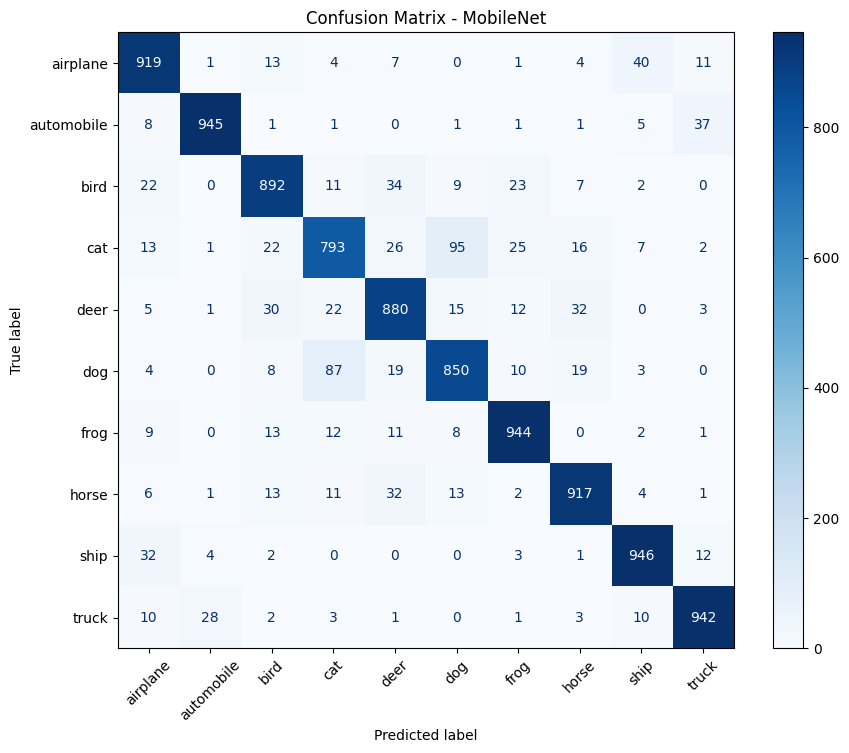

airplane is most confused with ship (40 times)
automobile is most confused with truck (37 times)
bird is most confused with deer (34 times)
cat is most confused with dog (95 times)
deer is most confused with horse (32 times)
dog is most confused with cat (87 times)
frog is most confused with bird (13 times)
horse is most confused with deer (32 times)
ship is most confused with airplane (32 times)
truck is most confused with automobile (28 times)


In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# CIFAR-10 class names
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# Predictions from MobileNet model
y_pred = model_mobilenet4.predict(x_test_preprocessed)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("Confusion Matrix - MobileNet")
plt.xticks(rotation=45)
plt.show()

# Show the main confusion for each class
for i in range(len(classes)):
    row = cm[i].copy()
    row[i] = 0
    most_confused_with = np.argmax(row)

    print(f"{classes[i]} is most confused with {classes[most_confused_with]} ({row[most_confused_with]} times)")

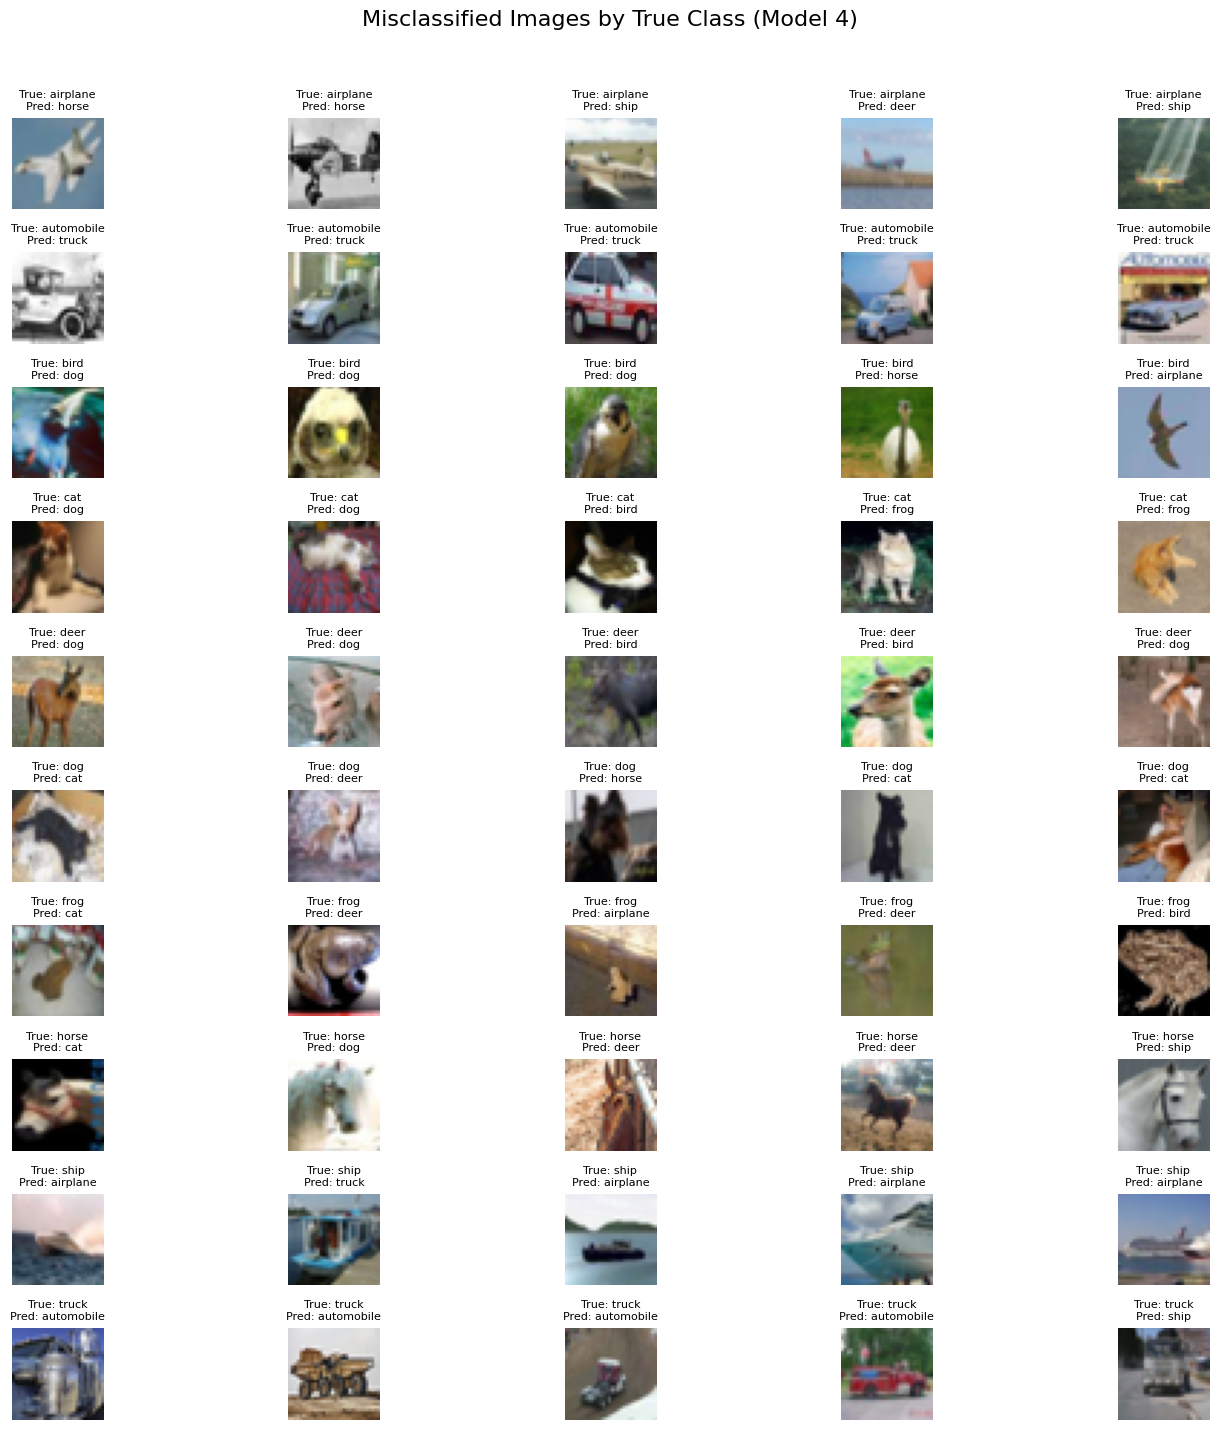

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# CIFAR-10 class names (standard order)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = 10

# Find misclassified images
misclassified_indices = np.where(y_true != y_pred_classes)[0]

# Dictionary to store misclassified images for each class
misclassified_samples_per_class = {i: [] for i in range(num_classes)}

# Populate the dictionary with a few misclassified samples (up to 5 per class)
for idx in misclassified_indices:
    true_class = y_true[idx]
    if len(misclassified_samples_per_class[true_class]) < 5:
        misclassified_samples_per_class[true_class].append(idx)

# Plotting the misclassified images
fig = plt.figure(figsize=(15, num_classes * 1.5)) # Adjust figure size dynamically
fig.suptitle('Misclassified Images by True Class (Model 4)', fontsize=16)

# Keep track of the subplot index
plot_idx = 1

for class_idx in range(num_classes):
    samples = misclassified_samples_per_class[class_idx]
    if samples:
        for i, img_idx in enumerate(samples):
            ax = fig.add_subplot(num_classes, 5, plot_idx) # Max 5 images per row for a class
            ax.imshow(x_test[img_idx]) # Use original x_test for plotting
            ax.axis('off')
            ax.set_title(f'True: {class_names[y_true[img_idx]]}\nPred: {class_names[y_pred_classes[img_idx]]}', fontsize=8)
            plot_idx += 1
    else:
       print(f"No misclassified samples found for class {class_names[class_idx]}")

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent title overlap
plt.show()

In [ ]:
# Save the model
model_mobilenet4.save("model_mobilenet4.keras")

In [ ]:
!pip install gradio

import keras
model_mobilenet2 = keras.saving.load_model("/content/model_mobilenet4.keras")

In [ ]:
import gradio as gr
import numpy as np
from PIL import Image

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def predict_image(img):

    img = img.resize((96, 96))

    arr = np.array(img) / 255.0

    if arr.shape[-1] == 4:
        arr = arr[..., :3]

    arr = np.expand_dims(arr, 0)

    prediction = model_mobilenet2.predict(arr)[0]

    return {class_names[i]: float(prediction[i]) for i in range(10)}

image_input = gr.Image(type="pil")
label_output = gr.Label(num_top_classes=3)

interface = gr.Interface(
    fn=predict_image,
    inputs=image_input,
    outputs=label_output,
    title="MobileNetV2 CIFAR-10 Classifier (Group 4)",
    description="Upload an image"
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://863c6748c8d787f05e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
